# =============================================================================
# NETWORK TRAFFIC ANALYSIS - EXPLORATORY DATA ANALYSIS
# =============================================================================

## Network Traffic Analysis

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project aims to analyze network traffic data to understand patterns, detect anomalies, and identify potential cyber attacks. The analysis will examine how different network protocols, services, and connection states relate to security threats.

### 2) Data Collection
- Dataset appears to be network traffic data with 45 columns and multiple rows
- The data includes features like protocol, service, packet counts, bytes transferred, and attack classifications

### 2.1 Import Data and Required Packages
#### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Go up one directory from 'notebook' to project root
project_root = os.path.dirname(os.getcwd())  # This goes up from 'notebook' to project root
balanced_data_path = os.path.join(project_root, 'artifacts', 'balanced_dataset.csv')

print(f"Looking for file at: {balanced_data_path}")
print(f"File exists: {os.path.exists(balanced_data_path)}")

# Load the data
df = pd.read_csv(balanced_data_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 records:")
df.head()

Looking for file at: c:\Users\Lenovo\OneDrive\Desktop\AgenticAICybersecurity\AgenticAICyberSecurities\artifacts\balanced_dataset.csv
File exists: True
Dataset shape: (4853245, 88)

First 5 records:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,http_method,status_code,uri,user_agent,scan_type,packet_info,extra_direction,flow_id,smb_command,smb_file
0,NaN,NaN,NaN,unknown,NaN,NaN,NaN,70.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,unknown,NaN,NaN,NaN,31.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,unknown,NaN,NaN,NaN,46.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,unknown,NaN,NaN,NaN,47.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Dataset information
Based on the provided data sample, here are the key features:

- **id**: Connection identifier
- **dur**: Duration of the connection
- **proto**: Protocol used (tcp, udp, etc.)
- **service**: Network service (ftp, http, etc.)
- **state**: Connection state (FIN, CON, etc.)
- **spkts**: Source to destination packet count
- **dpkts**: Destination to source packet count  
- **sbytes**: Source to destination bytes
- **dbytes**: Destination to source bytes
- **rate**: Connection rate
- **attack_cat**: Attack category
- **label**: Binary label (0: Normal, 1: Attack)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
print("Missing values in each column:")
print(df.isna().sum())
print(f"\nTotal missing values: {df.isna().sum().sum()}")

Missing values in each column:
id                 4711956
dur                4711956
proto              4711956
service            1664012
state              4711956
                    ...   
packet_info        4633649
extra_direction    4852261
flow_id            4155615
smb_command        4853119
smb_file           4853119
Length: 88, dtype: int64

Total missing values: 349928770


### 3.2 Check Duplicates

In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 1064927


### 3.3 Check data types

In [8]:
print("Data types information:")
df.info()

Data types information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853245 entries, 0 to 4853244
Data columns (total 88 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   id                        float64
 1   dur                       float64
 2   proto                     object 
 3   service                   object 
 4   state                     object 
 5   spkts                     float64
 6   dpkts                     float64
 7   sbytes                    float64
 8   dbytes                    float64
 9   rate                      float64
 10  sttl                      float64
 11  dttl                      float64
 12  sload                     float64
 13  dload                     float64
 14  sloss                     float64
 15  dloss                     float64
 16  sinpkt                    float64
 17  dinpkt                    float64
 18  sjit                      float64
 19  djit                      float64
 20  

### 3.4 Checking the number of unique values of each column

In [9]:
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
id                 141289
dur                 53655
proto                 132
service                14
state                   8
                    ...  
packet_info             2
extra_direction         1
flow_id            417429
smb_command            11
smb_file                1
Length: 88, dtype: int64


### 3.5 Check statistics of data set

In [10]:
print("Statistical summary of numerical features:")
df.describe()

Statistical summary of numerical features:


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,label,is_threat,extra_flow_id,extra_src_port,extra_dest_port,extra_icmp_type,extra_icmp_code,extra_tx_id,extra_response_icmp_type,extra_response_icmp_code
count,141289.000000,141289.000000,141289.000000,141289.000000,3.061439e+06,1.412890e+05,3.175931e+06,141289.000000,141289.000000,1.412890e+05,...,141289.000000,4.853245e+06,7.171480e+05,717140.000000,717140.000000,48.000000,48.000000,1952.000000,10.0,10.0
mean,100594.906688,1.443153,17.819632,14.427549,9.038853e+02,1.110087e+04,5.121132e+03,204.637891,83.257494,8.575039e+07,...,0.844659,6.000000e-01,1.072543e+15,39157.196517,32306.861386,6.458333,4.250000,0.318648,0.0,0.0
std,46129.079772,6.818747,149.816556,111.053983,4.234392e+04,1.445360e+05,4.399372e+04,89.213645,115.214423,1.951081e+08,...,0.362231,4.898980e-01,5.773001e+14,5701.945790,19197.382883,3.087093,4.455453,4.789993,0.0,0.0
min,1.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000e+00,8.640675e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,64510.000000,0.000007,2.000000,0.000000,6.000000e+00,0.000000e+00,0.000000e+00,254.000000,0.000000,1.339643e+04,...,1.000000,0.000000e+00,6.544031e+14,34297.000000,15576.000000,8.000000,0.000000,0.000000,0.0,0.0
50%,102847.000000,0.000010,2.000000,0.000000,5.800000e+01,0.000000e+00,0.000000e+00,254.000000,0.000000,5.066666e+07,...,1.000000,1.000000e+00,1.022670e+15,34297.000000,32302.000000,8.000000,1.500000,0.000000,0.0,0.0
75%,140019.000000,0.674005,10.000000,8.000000,3.190000e+02,6.120000e+02,0.000000e+00,254.000000,252.000000,9.120000e+07,...,1.000000,1.000000e+00,1.478507e+15,45191.000000,48974.000000,8.000000,9.000000,0.000000,0.0,0.0
max,175341.000000,59.999985,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,1.000000,1.000000e+00,2.251798e+15,65037.000000,65535.000000,8.000000,9.000000,90.000000,0.0,0.0


### 3.6 Check statistics of categorical data

In [11]:
print("Statistical summary of categorical features:")
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols].describe()

Statistical summary of categorical features:


,proto,service,state,attack_cat,timestamp,source_ip,target_ip,source_port,target_port,protocol,...,http_method,status_code,uri,user_agent,scan_type,packet_info,extra_direction,flow_id,smb_command,smb_file
count,141289,3189233,141289,141289,4711956,4597464,4597464,3617780.0,3617780.0,4563582,...,9120,9120.0,27960,27960,917642,219596,984,697630,126,126
unique,132,14,8,10,1125808,13682,16889,111722.0,134897.0,10,...,2,6.0,12032,5,5,2,1,417429,11,1
top,tcp,unknown,INT,Generic,2026-04-27T11:54:06.017396,192.168.100.20,192.168.100.10,0.0,80.0,TCP,...,GET,404.0,/protected/,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,standard_scan,unknown,to_server,unknown,SMB2_COMMAND_KEEPALIVE,unknown
freq,56164,3034642,78808,40000,41,1672694,1664694,1290177.0,843111.0,1523184,...,9104,8941.0,322,18668,697630,218904,984,72,74,126


### 3.7 Exploring Data

In [12]:
print("Categories in 'proto' variable:     ", end=" ")
print(df['proto'].unique())

print("Categories in 'service' variable:  ", end=" ")
print(df['service'].unique())

print("Categories in 'state' variable:     ", end=" ")
print(df['state'].unique())

print("Categories in 'attack_cat' variable:", end=" ")
print(df['attack_cat'].unique())

print("Categories in 'label' variable:     ", end=" ")
print(df['label'].unique())

Categories in 'proto' variable:      [nan 'udp' 'tcp' 'leaf-1' 'unas' 'pim' 'pipe' 'dcn' 'cftp' 'sctp' 'arp'
 'rdp' 'ospf' 'ipv6-frag' 'fire' 'sm' 'iso-tp4' 'zero' 'stp' 'eigrp'
 'pnni' 'emcon' '3pc' 'leaf-2' 'sccopmce' 'hmp' 'egp' 'iso-ip' 'ax.25'
 'gre' 'mobile' 'igp' 'xns-idp' 'isis' 'snp' 'aris' 'cpnx' 'ipnip' 'crudp'
 'idpr-cmtp' 'crtp' 'ddp' 'icmp' 'wsn' 'scps' 'trunk-2' 'merit-inp'
 'ipv6-route' 'any' 'nsfnet-igp' 'skip' 'st2' 'wb-expak' 'ptp' 'vmtp'
 'vines' 'pgm' 'rvd' 'trunk-1' 'ipcv' 'mhrp' 'cphb' 'bna' 'pri-enc'
 'swipe' 'xtp' 'nvp' 'narp' 'idrp' 'rsvp' 'mux' 'smp' 'ggp' 'il' 'ddx'
 'ippc' 'argus' 'mfe-nsp' 'irtp' 'sps' 'bbn-rcc' 'larp' 'ip' 'uti'
 'sun-nd' 'secure-vmtp' 'a/n' 'tcf' 'sat-mon' 'compaq-peer' 'netblt' 'pup'
 'prm' 'br-sat-mon' 'idpr' 'cbt' 'kryptolan' 'sat-expak' 'micp' 'ib'
 'sprite-rpc' 'gmtp' 'sep' 'l2tp' 'pvp' 'ipv6-no' 'fc' 'iplt' 'dgp' 'ipip'
 'ipv6' 'xnet' 'ipx-n-ip' 'ifmp' 'iatp' 'ttp' 'etherip' 'vrrp' 'aes-sp3-d'
 'wb-mon' 'sdrp' 'ipv6-opts' 'visa' 's

In [13]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 50 numerical features : ['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label', 'is_threat', 'extra_flow_id', 'extra_src_port', 'extra_dest_port', 'extra_icmp_type', 'extra_icmp_code', 'extra_tx_id', 'extra_response_icmp_type', 'extra_response_icmp_code']

We have 38 categorical features : ['proto', 'service', 'state', 'attack_cat', 'timestamp', 'source_ip', 'target_ip', 'source_port', 'target_port', 'protocol', 'tool', 'description', 'attack_category', 'severity', 'dataset_source', 'event_type', 'file_source', 'extra_in_iface', 'extra_src_ip', 'extra_dest_ip', 'extra

### 3.8 Adding derived features for better analysis

In [14]:
# Calculate total packets and bytes
df['total_packets'] = df['spkts'] + df['dpkts']
df['total_bytes'] = df['sbytes'] + df['dbytes']
df['packet_size_ratio'] = df['sbytes'] / (df['spkts'] + 1)  # Adding 1 to avoid division by zero

print("Added derived features:")
print(df[['total_packets', 'total_bytes', 'packet_size_ratio']].head())

Added derived features:
   total_packets  total_bytes  packet_size_ratio
0            NaN          NaN                NaN
1            NaN          NaN                NaN
2            NaN          NaN                NaN
3            NaN          NaN                NaN
4            NaN          NaN                NaN


In [15]:
# Check attack distribution
attack_counts = df['attack_category'].value_counts()
label_counts = df['is_threat'].value_counts()

print("Attack category distribution:")
print(attack_counts)
print(f"\nLabel distribution (0: Normal, 1: Attack):")
print(label_counts)
print(f"\nAttack percentage: {(label_counts[1] / len(df) * 100):.2f}%")

Attack category distribution:
attack_category
normal                  1919350
reconnaissance          1016410
dos_testing              980972
bruteforce               492426
web_scanning             284588
directory_bruteforce       9122
unknown                    4646
malware                    3932
network_scanning            416
exploitation                 94
Name: count, dtype: int64

Label distribution (0: Normal, 1: Attack):
is_threat
1    2911947
0    1941298
Name: count, dtype: int64

Attack percentage: 60.00%


### 4. Exploring Data (Visualization)

#### 4.1 Visualize attack distribution

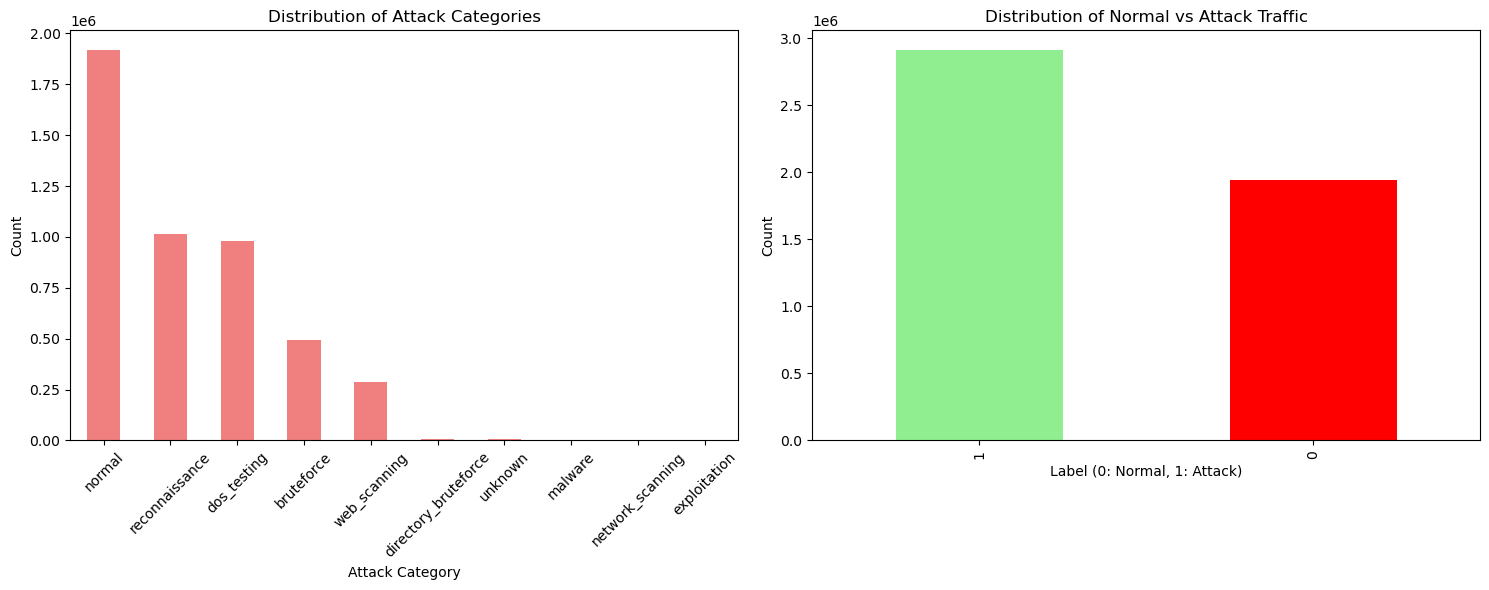

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Attack categories
plt.subplot(1, 2, 1)
attack_counts.plot(kind='bar', color='lightcoral')
plt.title('Distribution of Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Binary labels
plt.subplot(1, 2, 2)
label_counts.plot(kind='bar', color=['lightgreen', 'red'])
plt.title('Distribution of Normal vs Attack Traffic')
plt.xlabel('Label (0: Normal, 1: Attack)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### 4.2 Protocol and Service Analysis

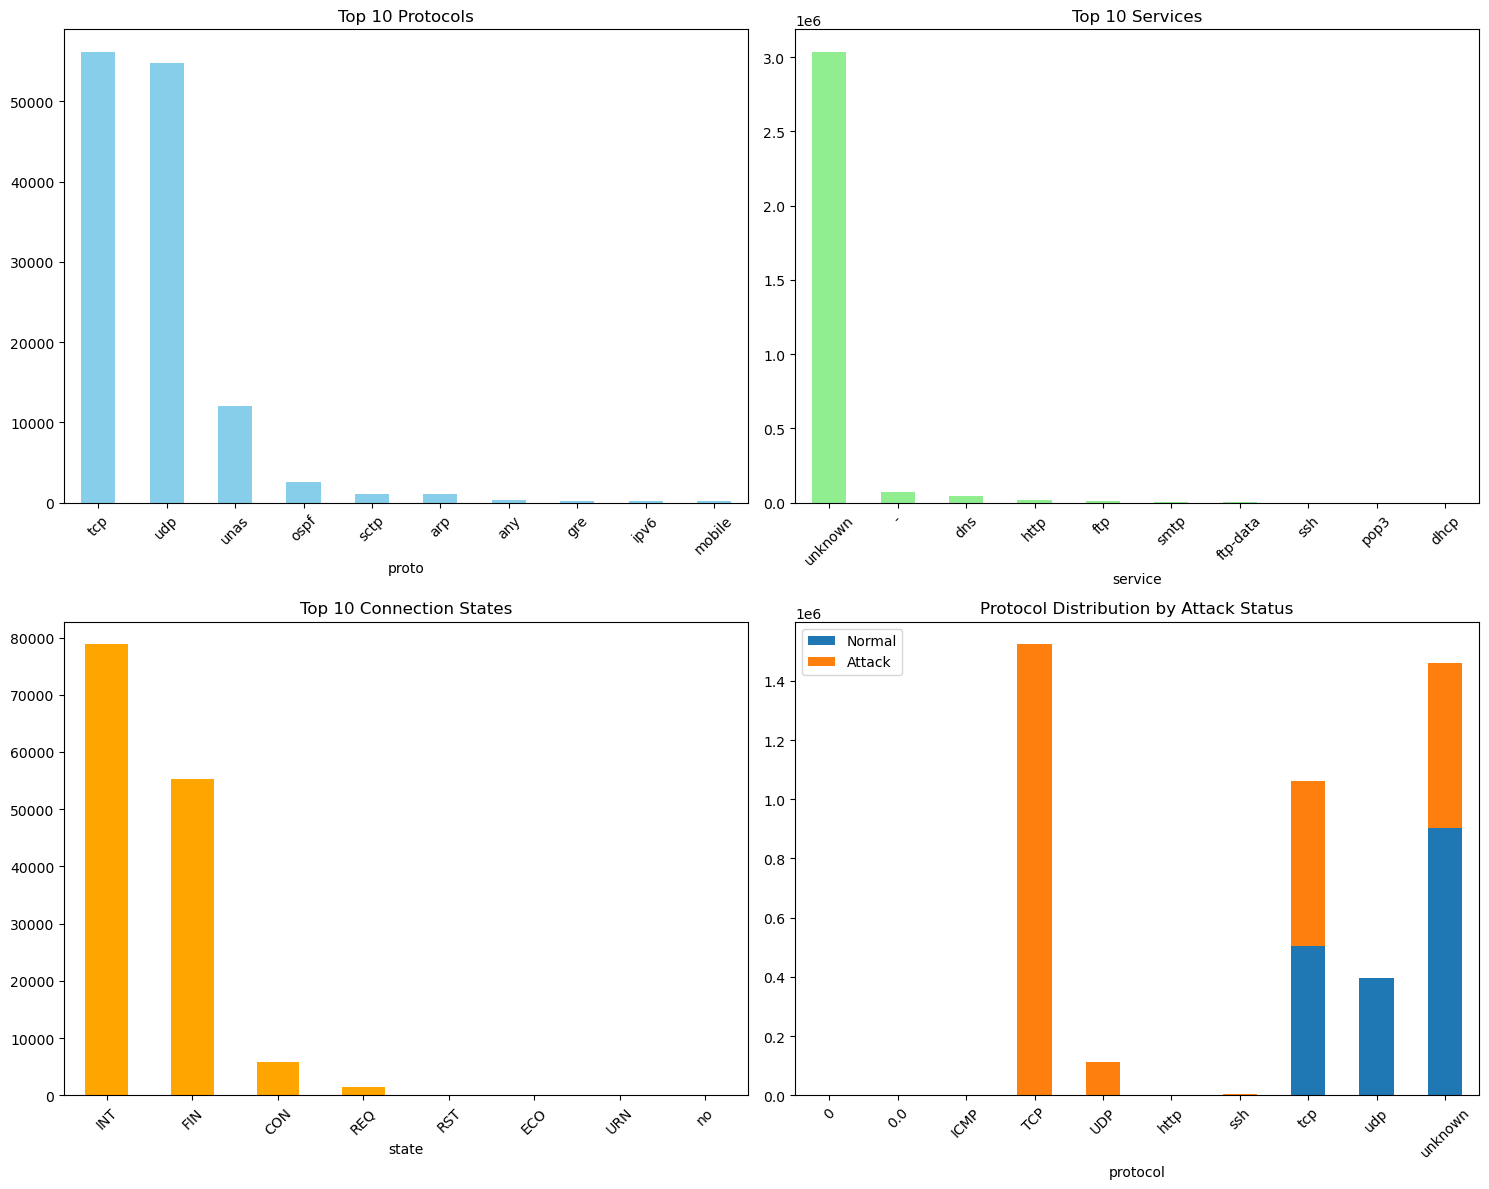

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Protocol distribution
plt.subplot(2, 2, 1)
df['proto'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Protocols')
plt.xticks(rotation=45)

# Service distribution
plt.subplot(2, 2, 2)
df['service'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Services')
plt.xticks(rotation=45)

# Connection state distribution
plt.subplot(2, 2, 3)
df['state'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Connection States')
plt.xticks(rotation=45)

# Protocol vs Attack
plt.subplot(2, 2, 4)
protocol_attack = pd.crosstab(df['protocol'], df['is_threat'])
protocol_attack.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Protocol Distribution by Attack Status')
plt.xticks(rotation=45)
plt.legend(['Normal', 'Attack'])

plt.tight_layout()
plt.show()

#### 4.3 Numerical Features Distribution

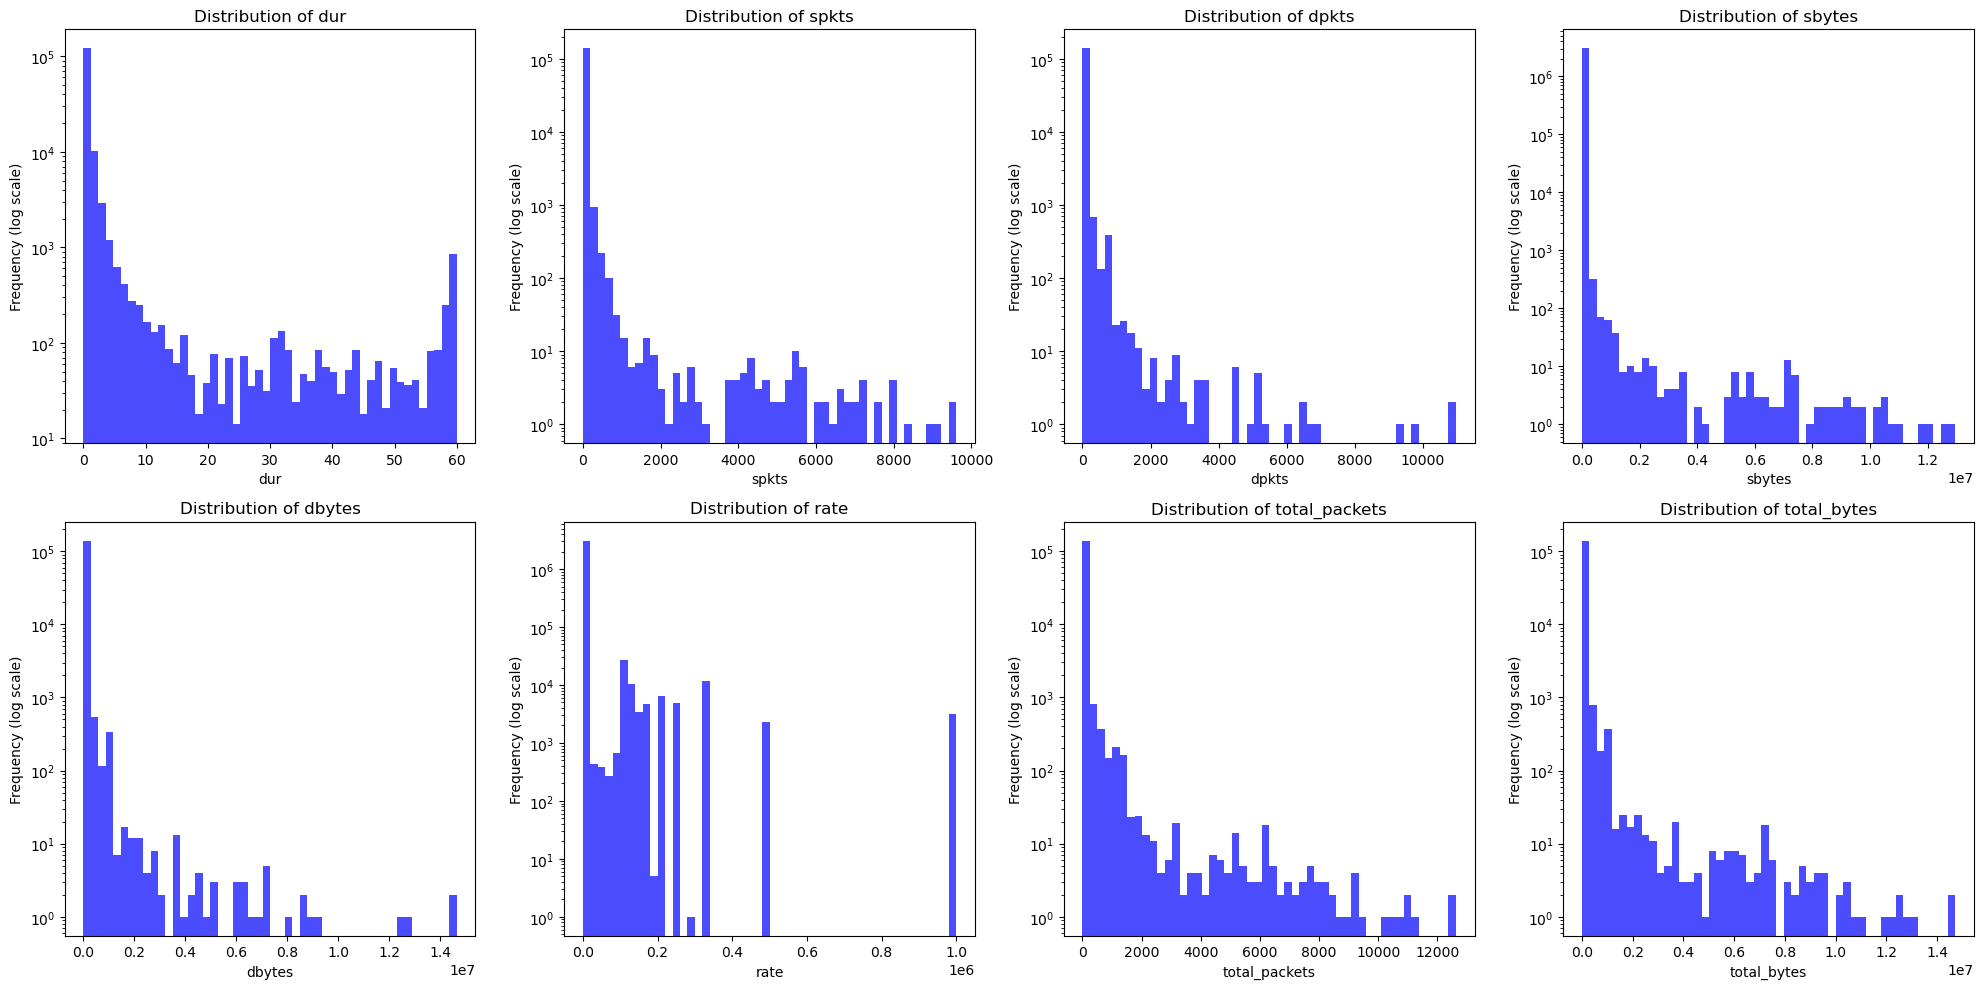

In [18]:
# Select key numerical features for analysis
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'total_packets', 'total_bytes']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    # Use log scale for better visualization of skewed data
    axes[i].hist(df[feature], bins=50, alpha=0.7, color='blue', log=True)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

#### 4.4 Correlation Analysis

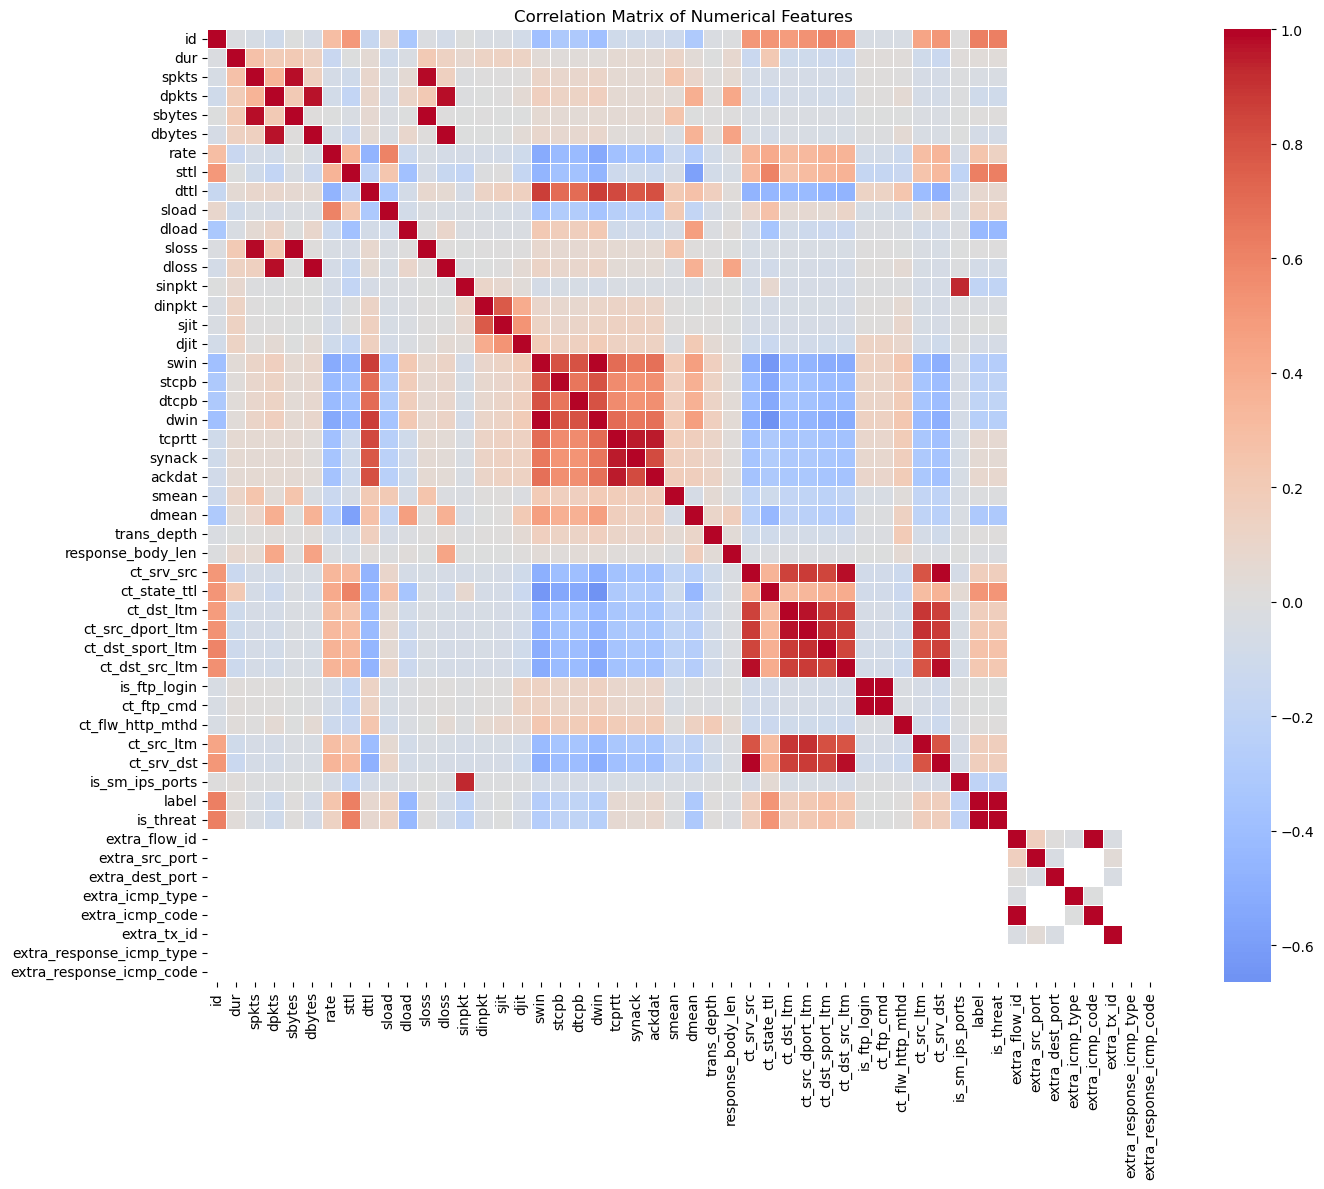

Top 10 features correlated with label:
is_threat           1.000000
label               1.000000
id                  0.621233
sttl                0.620976
ct_state_ttl        0.514554
ct_dst_sport_ltm    0.259895
rate                0.246768
ct_dst_src_ltm      0.222592
ct_src_dport_ltm    0.220053
ct_src_ltm          0.172803
Name: label, dtype: float64


In [19]:

# Calculate correlation matrix for numerical features
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Show top correlations with label
label_correlations = correlation_matrix['label'].sort_values(ascending=False)
print("Top 10 features correlated with label:")
print(label_correlations.head(10))

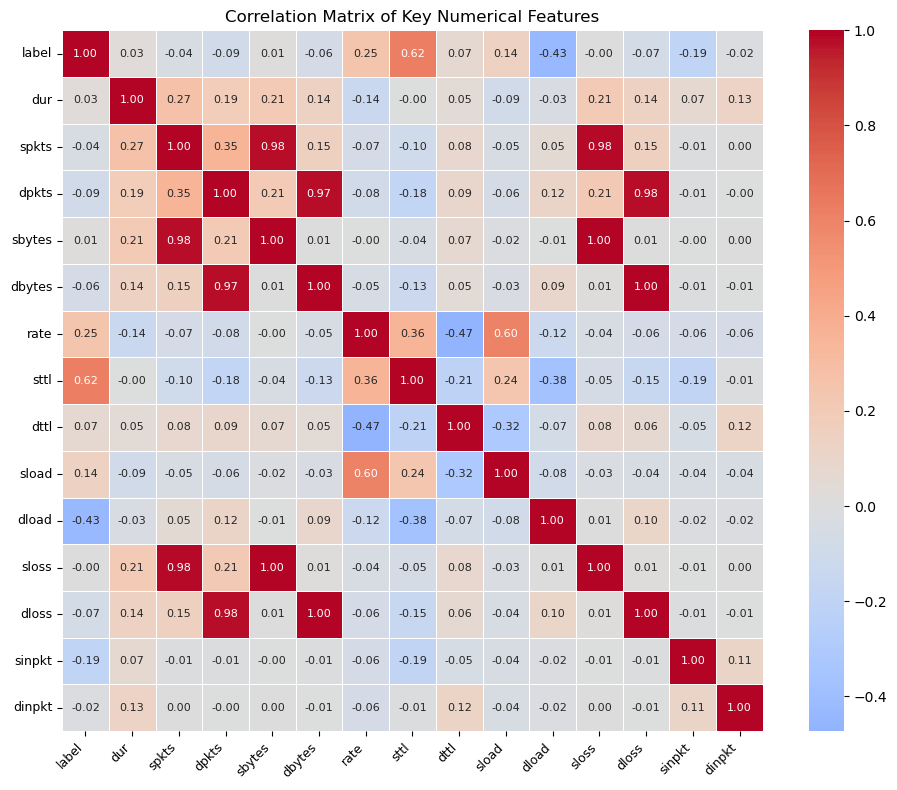


Top features correlated with label:
  sttl: 0.621
  rate: 0.247
  sload: 0.135
  dttl: 0.072
  dur: 0.026
  sbytes: 0.013
  sloss: -0.001
  dinpkt: -0.023


In [20]:
# Calculate correlation matrix for top numerical features only
# Select top 15 features most relevant to label
top_features = ['label', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 
                'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 
                'dloss', 'sinpkt', 'dinpkt']

# Create reduced correlation matrix
correlation_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            annot_kws={'size': 8})
plt.title('Correlation Matrix of Key Numerical Features', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Show top correlations with label
label_correlations = correlation_matrix['label'].drop('label').sort_values(ascending=False)
print("\nTop features correlated with label:")
for feature, corr in label_correlations.head(8).items():
    print(f"  {feature}: {corr:.3f}")

#### 4.5 Attack Patterns Analysis

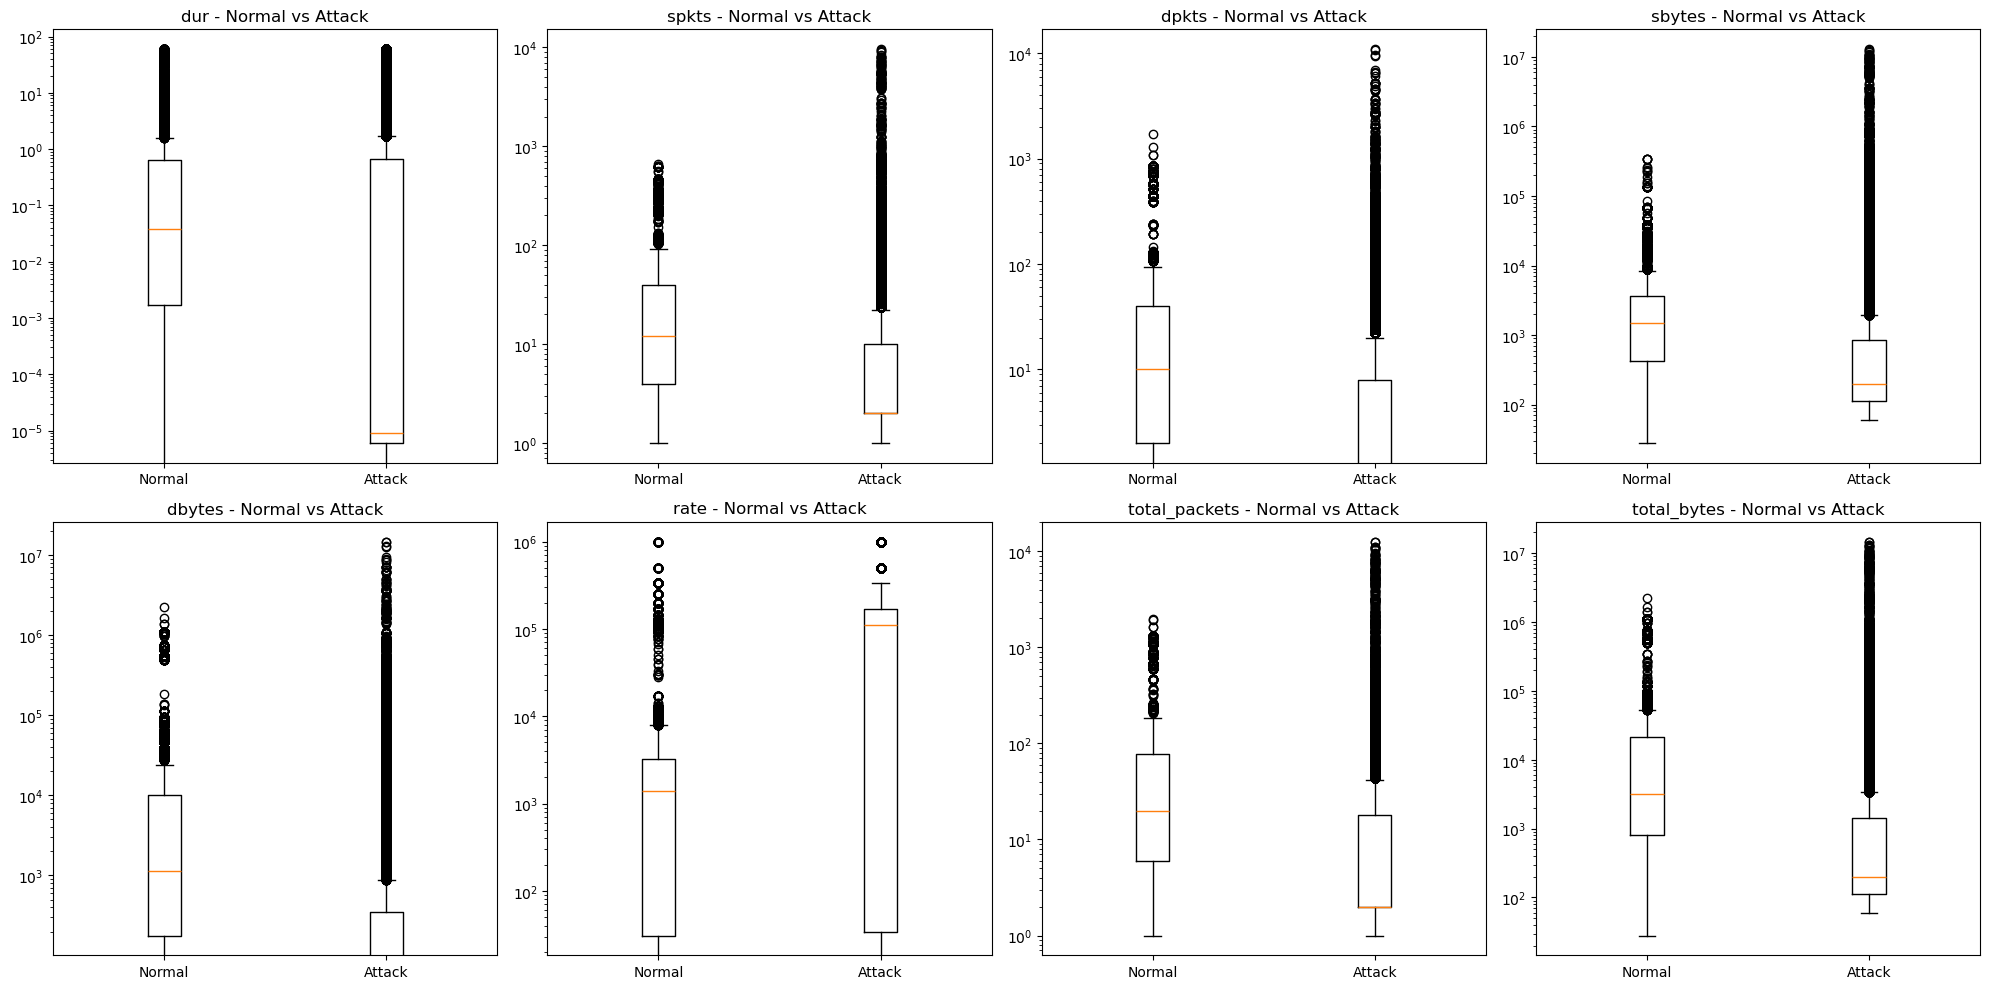

In [21]:

# Compare numerical features between normal and attack traffic
comparison_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'total_packets', 'total_bytes']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(comparison_features):
    # Create box plots for normal vs attack
    normal_data = df[df['label'] == 0][feature]
    attack_data = df[df['label'] == 1][feature]
    
    # Use log scale for better visualization
    data_to_plot = [normal_data, attack_data]
    axes[i].boxplot(data_to_plot, labels=['Normal', 'Attack'])
    axes[i].set_title(f'{feature} - Normal vs Attack')
    axes[i].set_yscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.show()

#### 4.6 Protocol-Service Analysis

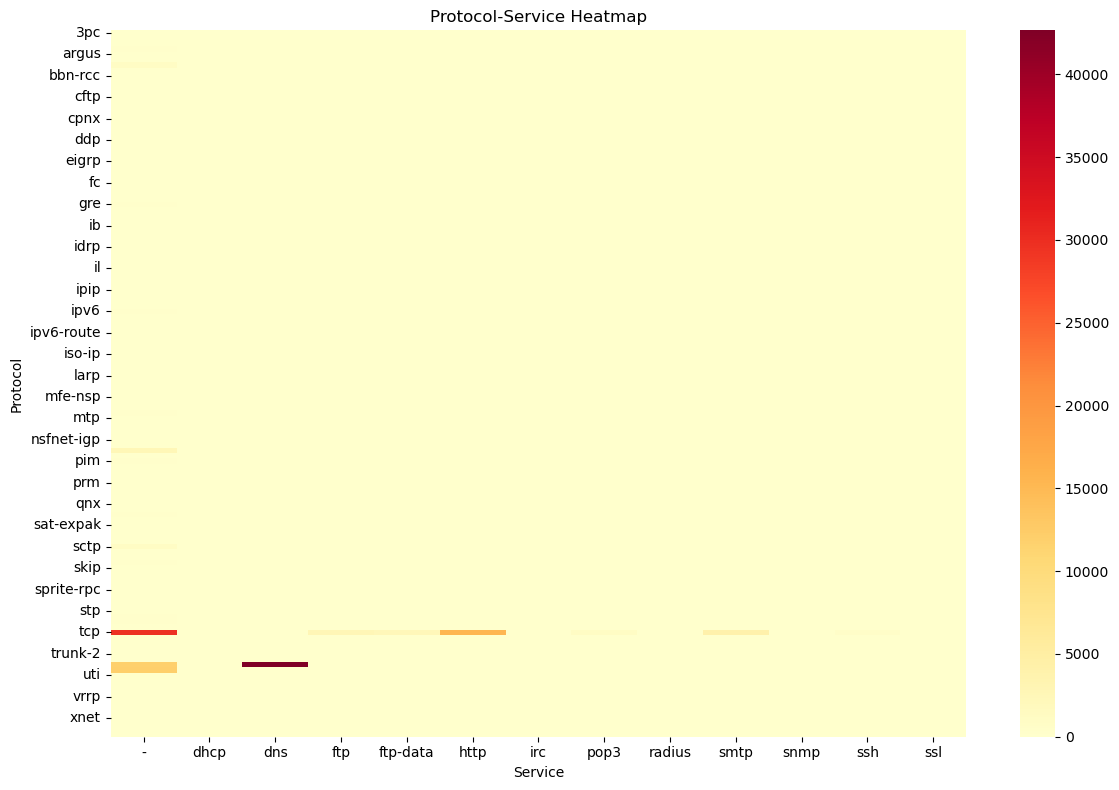

In [22]:

# Create cross-tabulation of protocol and service
protocol_service = pd.crosstab(df['proto'], df['service'])
plt.figure(figsize=(12, 8))
sns.heatmap(protocol_service, cmap='YlOrRd', annot=False)
plt.title('Protocol-Service Heatmap')
plt.xlabel('Service')
plt.ylabel('Protocol')
plt.tight_layout()
plt.show()

#### 4.7 Duration Analysis by Attack Type

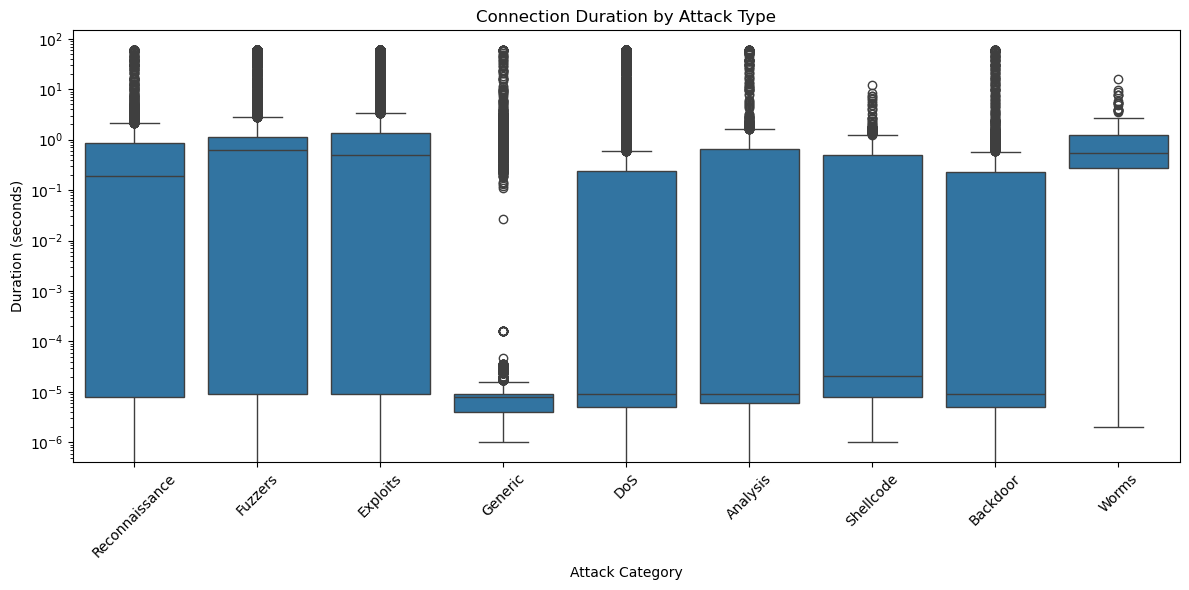

In [23]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='attack_cat', y='dur', data=df[df['label'] == 1])
plt.title('Connection Duration by Attack Type')
plt.xlabel('Attack Category')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.yscale('log')  # Log scale for better visualization
plt.tight_layout()
plt.show()

#### 4.8 Packet and Byte Analysis

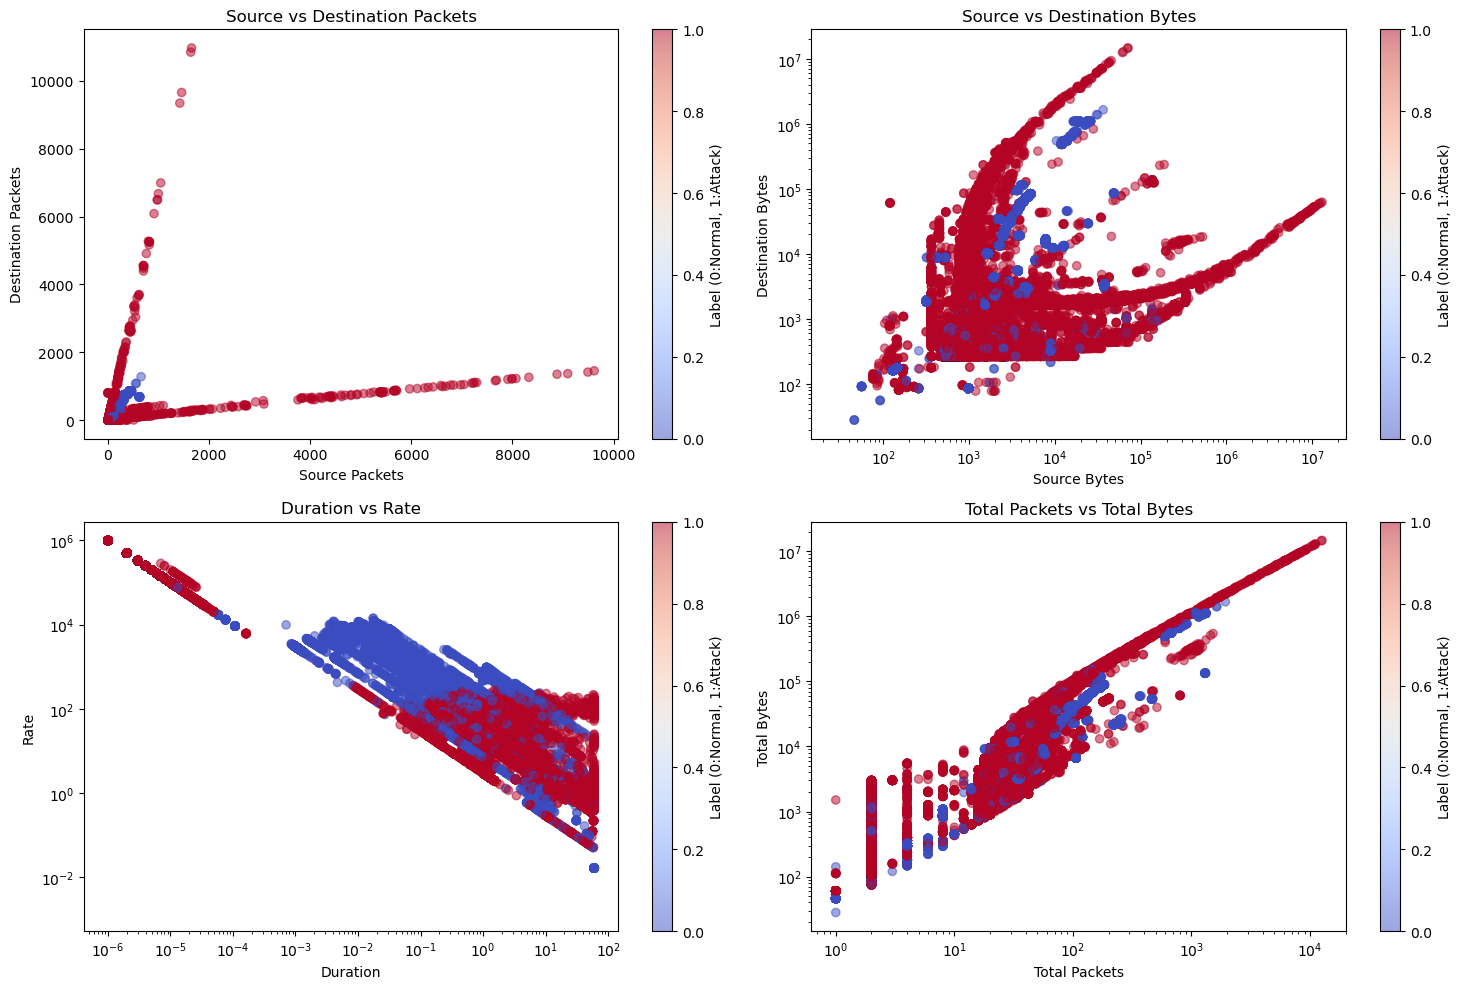

In [24]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Source vs Destination packets
plt.subplot(2, 2, 1)
plt.scatter(df['spkts'], df['dpkts'], alpha=0.5, c=df['is_threat'], cmap='coolwarm')
plt.xlabel('Source Packets')
plt.ylabel('Destination Packets')
plt.title('Source vs Destination Packets')
plt.colorbar(label='Label (0:Normal, 1:Attack)')

# Source vs Destination bytes
plt.subplot(2, 2, 2)
plt.scatter(df['sbytes'], df['dbytes'], alpha=0.5, c=df['is_threat'], cmap='coolwarm')
plt.xlabel('Source Bytes')
plt.ylabel('Destination Bytes')
plt.title('Source vs Destination Bytes')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

# Rate vs Duration
plt.subplot(2, 2, 3)
plt.scatter(df['dur'], df['rate'], alpha=0.5, c=df['is_threat'], cmap='coolwarm')
plt.xlabel('Duration')
plt.ylabel('Rate')
plt.title('Duration vs Rate')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

# Total packets vs Total bytes
plt.subplot(2, 2, 4)
plt.scatter(df['total_packets'], df['total_bytes'], alpha=0.5, c=df['label'], cmap='coolwarm')
plt.xlabel('Total Packets')
plt.ylabel('Total Bytes')
plt.title('Total Packets vs Total Bytes')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()

#### 4.9 Connection State Analysis

<Figure size 1000x600 with 0 Axes>

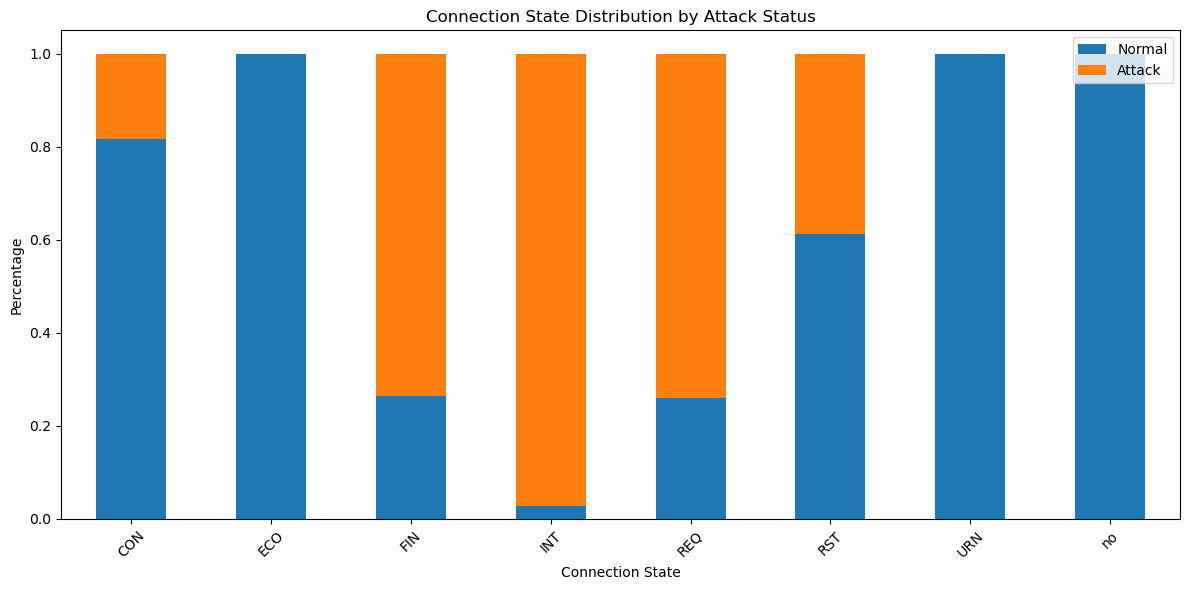

In [25]:

plt.figure(figsize=(10, 6))
state_attack = pd.crosstab(df['state'], df['label'])
state_attack_percentage = state_attack.div(state_attack.sum(1), axis=0)

state_attack_percentage.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Connection State Distribution by Attack Status')
plt.xlabel('Connection State')
plt.ylabel('Percentage')
plt.legend(['Normal', 'Attack'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.10 Feature Importance Analysis

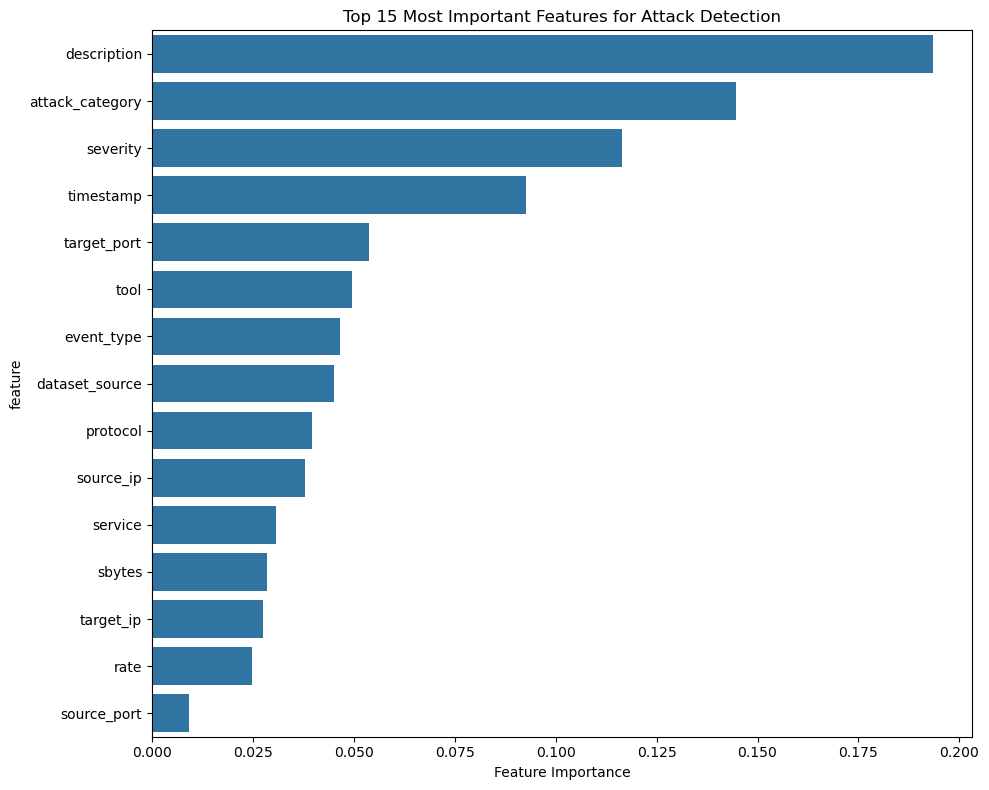

Top 10 most important features:
            feature  importance
51      description    0.193390
52  attack_category    0.144589
53         severity    0.116418
44        timestamp    0.092678
48      target_port    0.053770
50             tool    0.049639
55       event_type    0.046534
54   dataset_source    0.045057
49         protocol    0.039597
45        source_ip    0.038043


In [28]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare data for feature importance
df_encoded = df.copy()

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    if col != 'attack_cat':  # We'll keep attack_cat as is for now
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Separate features and target
X = df_encoded.drop(['attack_cat', 'is_threat'], axis=1)
y = df_encoded['is_threat']

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Most Important Features for Attack Detection')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))

#### 4.11 Time-based Analysis (if timestamp available)

Time-based features found: ['timestamp']


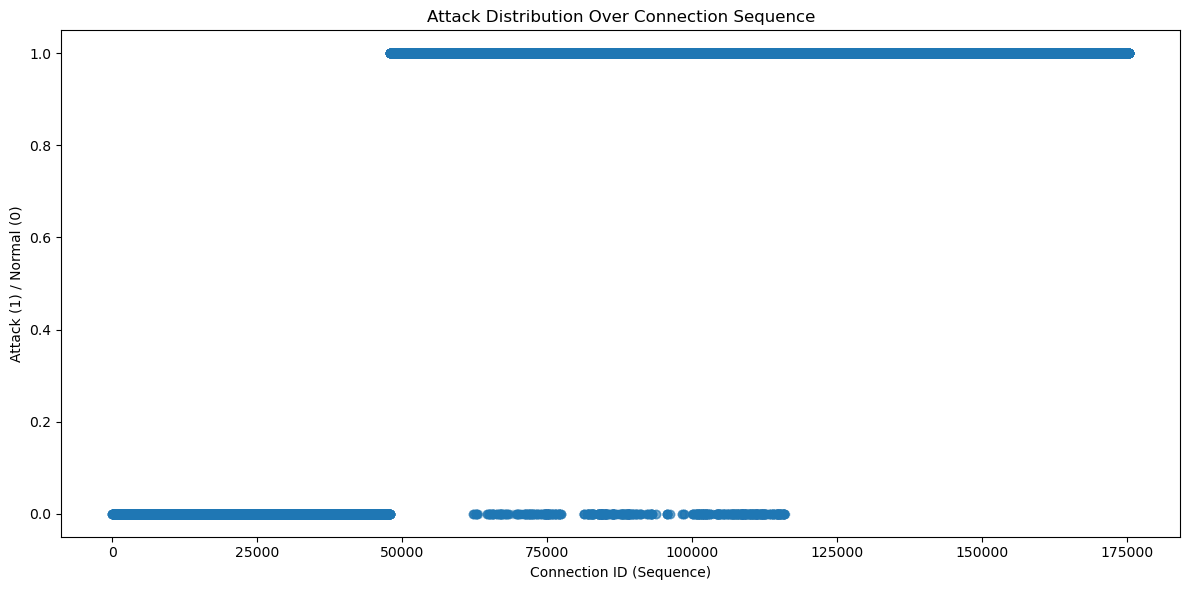

In [29]:

# Check if there's any time-based feature
time_based_features = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
print("Time-based features found:", time_based_features)

# If no explicit time feature, we can use id as proxy for connection sequence
if 'id' in df.columns:
    plt.figure(figsize=(12, 6))
    plt.scatter(df['id'], df['label'], alpha=0.1)
    plt.xlabel('Connection ID (Sequence)')
    plt.ylabel('Attack (1) / Normal (0)')
    plt.title('Attack Distribution Over Connection Sequence')
    plt.tight_layout()
    plt.show()

#### 4.12 Multivariate Analysis using PairPlot

Unique label values: [nan  1.  0.]
Unique is_threat values: [0 1]
Threat count: 119341, Normal count: 4733904


<Figure size 1200x1000 with 0 Axes>

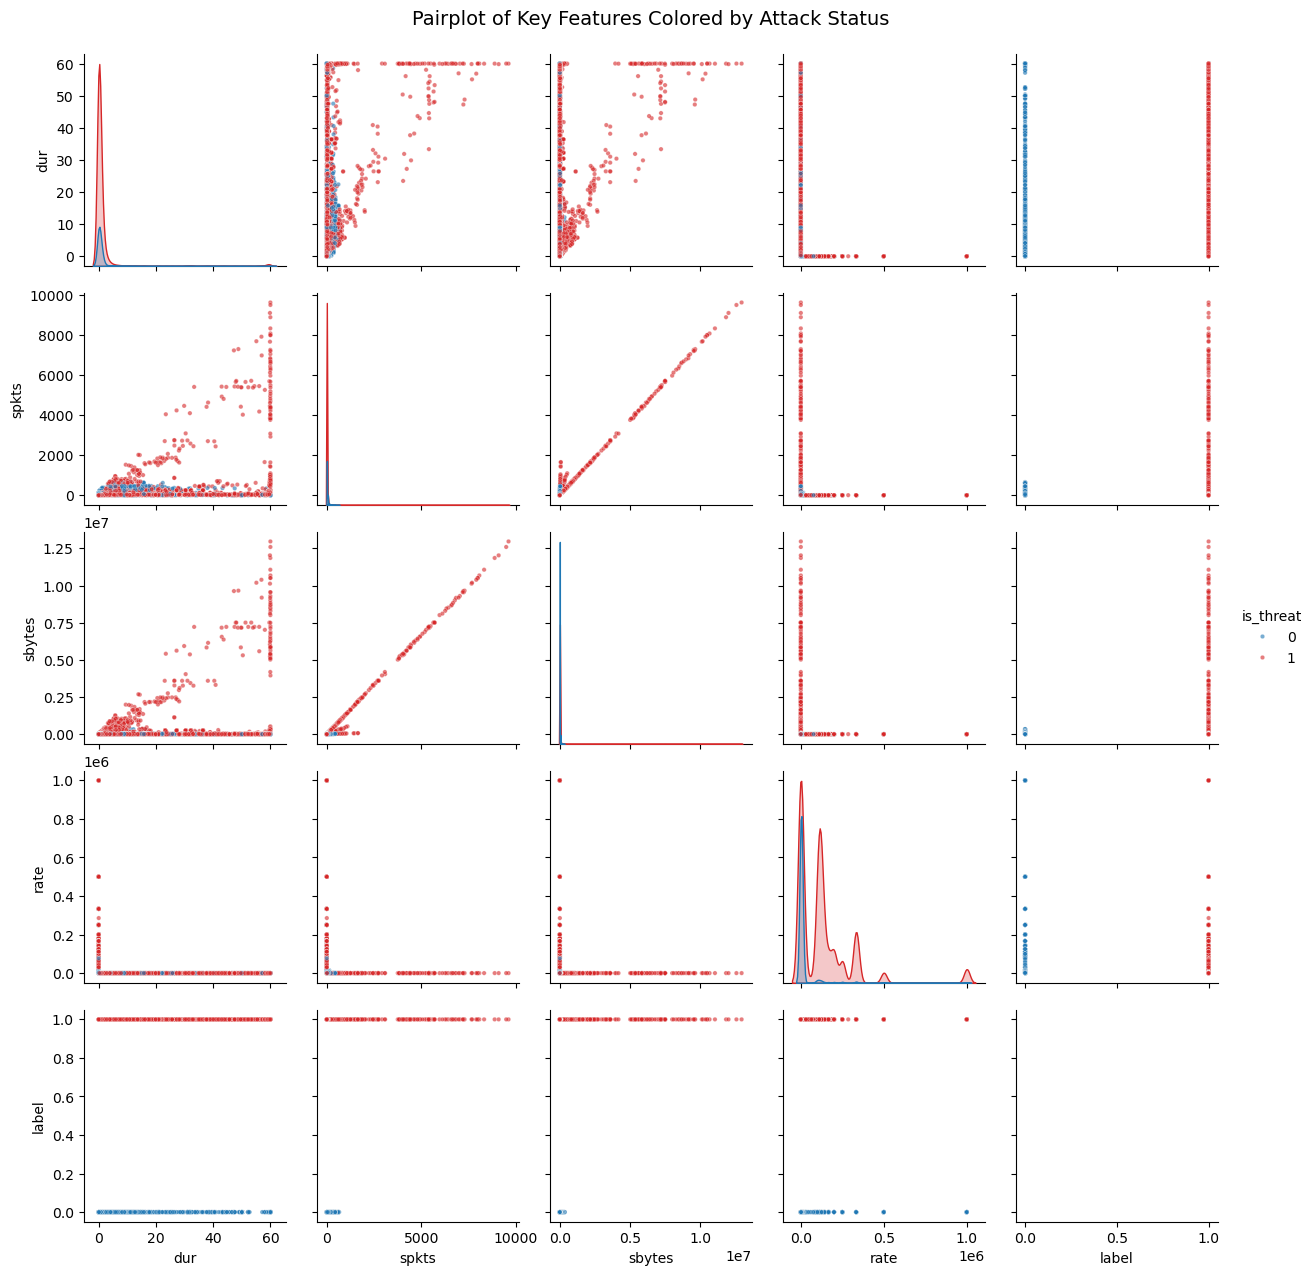

In [32]:
# First, check your label values
print("Unique label values:", df['label'].unique())

# Create is_threat column based on your label values
if df['label'].dtype in ['int64', 'float64']:
    df['is_threat'] = df['label']
elif df['label'].dtype == 'object':
    attack_values = ['attack', 'malicious', 'abnormal', '1']
    df['is_threat'] = df['label'].apply(lambda x: 1 if str(x).lower() in attack_values else 0)
elif 'Normal' in df['label'].values or 'Attack' in df['label'].values:
    df['is_threat'] = (df['label'] == 'Attack').astype(int)

# Handle NaN values if present
df['is_threat'] = df['is_threat'].fillna(0).astype(int)

print("Unique is_threat values:", df['is_threat'].unique())
print(f"Threat count: {df['is_threat'].sum()}, Normal count: {len(df) - df['is_threat'].sum()}")

# IMPORTANT: Include 'is_threat' in the DataFrame for pairplot
# Create a DataFrame that includes both your features AND the hue column
key_features_pair = ['dur', 'spkts', 'sbytes', 'rate', 'label']
plot_df = df[key_features_pair + ['is_threat']].copy()

# Drop rows with NaN in the features or is_threat (if any)
plot_df = plot_df.dropna()

# Now create the pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(plot_df, 
             hue='is_threat', 
             palette={0: '#1f77b4', 1: '#d62728'},  # Blue for normal, red for threat
             diag_kind='kde', 
             plot_kws={'alpha': 0.6, 's': 10})
plt.suptitle('Pairplot of Key Features Colored by Attack Status', y=1.02, fontsize=14)
plt.show()

### 5. Key Insights and Conclusions

In [33]:
print("="*50)
print("KEY INSIGHTS FROM EDA")
print("="*50)

# 1. Data Overview
print(f"1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df)}")
print(f"   - Features: {len(df.columns)}")
print(f"   - Attack rate: {(df['label'].mean() * 100):.2f}%")

# 2. Attack Distribution
attack_dist = df['attack_cat'].value_counts()
print(f"\n2. ATTACK DISTRIBUTION:")
for attack, count in attack_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   - {attack}: {count} ({percentage:.2f}%)")

# 3. Protocol Analysis
print(f"\n3. PROTOCOL ANALYSIS:")
proto_attack_rate = df.groupby('proto')['label'].mean().sort_values(ascending=False)
print(f"   - Most dangerous protocol: {proto_attack_rate.index[0]} ({proto_attack_rate.iloc[0]*100:.1f}% attack rate)")

# 4. Service Analysis
print(f"\n4. SERVICE ANALYSIS:")
service_attack_rate = df.groupby('service')['label'].mean().sort_values(ascending=False)
print(f"   - Most dangerous service: {service_attack_rate.index[0]} ({service_attack_rate.iloc[0]*100:.1f}% attack rate)")

# 5. Key Differences
print(f"\n5. KEY DIFFERENCES BETWEEN NORMAL AND ATTACK TRAFFIC:")
normal_stats = df[df['label'] == 0][['dur', 'spkts', 'sbytes', 'rate']].median()
attack_stats = df[df['label'] == 1][['dur', 'spkts', 'sbytes', 'rate']].median()

for feature in ['dur', 'spkts', 'sbytes', 'rate']:
    normal_val = normal_stats[feature]
    attack_val = attack_stats[feature]
    ratio = attack_val / normal_val if normal_val > 0 else float('inf')
    print(f"   - {feature}: Normal={normal_val:.2f}, Attack={attack_val:.2f}, Ratio={ratio:.2f}x")

# 6. Feature Importance
print(f"\n6. MOST IMPORTANT FEATURES FOR DETECTION:")
top_features = feature_importance.head(5)
for _, row in top_features.iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("="*50)

KEY INSIGHTS FROM EDA
1. DATASET OVERVIEW:
   - Total records: 4853245
   - Features: 91
   - Attack rate: 84.47%

2. ATTACK DISTRIBUTION:
   - Generic: 40000 (0.82%)
   - Exploits: 33393 (0.69%)
   - Normal: 21948 (0.45%)
   - Fuzzers: 18184 (0.37%)
   - DoS: 12264 (0.25%)
   - Reconnaissance: 10491 (0.22%)
   - Analysis: 2000 (0.04%)
   - Backdoor: 1746 (0.04%)
   - Shellcode: 1133 (0.02%)
   - Worms: 130 (0.00%)

3. PROTOCOL ANALYSIS:
   - Most dangerous protocol: 3pc (100.0% attack rate)

4. SERVICE ANALYSIS:
   - Most dangerous service: dhcp (100.0% attack rate)

5. KEY DIFFERENCES BETWEEN NORMAL AND ATTACK TRAFFIC:
   - dur: Normal=0.04, Attack=0.00, Ratio=0.00x
   - spkts: Normal=12.00, Attack=2.00, Ratio=0.17x
   - sbytes: Normal=1470.00, Attack=200.00, Ratio=0.14x
   - rate: Normal=1396.35, Attack=111111.11, Ratio=79.57x

6. MOST IMPORTANT FEATURES FOR DETECTION:
   - description: 0.1934
   - attack_category: 0.1446
   - severity: 0.1164
   - timestamp: 0.0927
   - target_port

### 6. Recommendations for Next Steps

In [34]:
print("RECOMMENDATIONS FOR MODEL BUILDING:")
print("1. DATA PREPROCESSING:")
print("   - Handle categorical variables (proto, service, state) using encoding")
print("   - Normalize numerical features due to different scales")
print("   - Consider log transformation for highly skewed features")

print("\n2. FEATURE ENGINEERING:")
print("   - Use derived features like packet_size_ratio, total_packets, total_bytes")
print("   - Consider interaction terms between key features")
print("   - Focus on top important features identified in EDA")

print("\n3. MODEL SELECTION:")
print("   - Binary classification: Random Forest, XGBoost, Neural Networks")
print("   - Multi-class classification for attack type prediction")
print("   - Consider anomaly detection algorithms for unknown attacks")

print("\n4. VALIDATION STRATEGY:")
print("   - Stratified sampling due to potential class imbalance")
print("   - Time-based split if temporal patterns exist")
print("   - Cross-validation for robust performance estimation")

print("\n5. PERFORMANCE METRICS:")
print("   - Focus on Recall (minimize false negatives)")
print("   - Monitor Precision (avoid too many false positives)")
print("   - Use F1-score for balanced evaluation")
print("   - Consider ROC-AUC for overall performance")

RECOMMENDATIONS FOR MODEL BUILDING:
1. DATA PREPROCESSING:
   - Handle categorical variables (proto, service, state) using encoding
   - Normalize numerical features due to different scales
   - Consider log transformation for highly skewed features

2. FEATURE ENGINEERING:
   - Use derived features like packet_size_ratio, total_packets, total_bytes
   - Consider interaction terms between key features
   - Focus on top important features identified in EDA

3. MODEL SELECTION:
   - Binary classification: Random Forest, XGBoost, Neural Networks
   - Multi-class classification for attack type prediction
   - Consider anomaly detection algorithms for unknown attacks

4. VALIDATION STRATEGY:
   - Stratified sampling due to potential class imbalance
   - Time-based split if temporal patterns exist
   - Cross-validation for robust performance estimation

5. PERFORMANCE METRICS:
   - Focus on Recall (minimize false negatives)
   - Monitor Precision (avoid too many false positives)
   - Use F1-